In [3]:
!pip install -q sentence-transformers umap-learn hdbscan

In [2]:
import pandas as pd
from tqdm import tqdm
import json
import requests
from datasets import load_dataset, get_dataset_config_names

вид датасета

In [3]:
schema = [
    "task_id",
    "benchmark",
    "task_type",
    "dataset_split",
    "question",
    "context",
    "options",
    "correct_answer"
]

бенчмарки с задачей mc

In [4]:
def load_hellaswag():

    dataset = load_dataset("hellaswag")

    rows = []

    for i, item in enumerate(dataset["validation"]):

        rows.append({
            "task_id": f"hellaswag_{i}",
            "benchmark": "hellaswag",
            "task_type": "multiple_choice",
            "dataset_split": "validation",
            "question": item["ctx"],
            "context": None,
            "options": item["endings"],
            "correct_answer": item["label"]
        })

    return pd.DataFrame(rows)



In [5]:
def load_fever():

    dataset = load_dataset("fever", "v2.0")

    rows = []

    for i, item in enumerate(dataset["validation"]):

        rows.append({
            "task_id": f"fever_{i}",
            "benchmark": "fever",
            "task_type": "fact_verification",
            "dataset_split": "validation",
            "question": item["claim"],
            "context": None,
            "options": ["SUPPORTS", "REFUTES", "NOT ENOUGH INFO"],
            "correct_answer": item["label"]
        })

    return pd.DataFrame(rows)

In [6]:
def load_hover():

    dataset = load_dataset("hover")

    rows = []

    for i, item in enumerate(dataset["validation"]):

        rows.append({
            "task_id": f"hover_{i}",
            "benchmark": "hover",
            "task_type": "multiple_choice",
            "dataset_split": "validation",
            "question": item["claim"],
            "context": None,
            "options": ["SUPPORTS", "REFUTES"],
            "correct_answer": "SUPPORTS" if item["label"] == 1 or item["label"] == "1" else "REFUTES"
        })

    return pd.DataFrame(rows)

In [7]:
def correct_answer_format_mmlu(correct_answer):
    if correct_answer==0 or correct_answer=="0":
        return "A"
    elif correct_answer==1 or correct_answer=="1":
        return "B"
    elif correct_answer==2 or correct_answer=="2":
        return "C"
    elif correct_answer==3 or correct_answer=="3":
        return "D"


def load_mmlu():

    dataset = load_dataset("cais/mmlu", "all")

    rows = []

    for i, item in enumerate(dataset["validation"]):

        rows.append({
            "task_id": f"mmlu_{i}",
            "benchmark": "mmlu",
            "task_type": "multiple_choice",
            "dataset_split": "validation",
            "question": item["question"],
            "context": None,
            "options": item["choices"],
            "correct_answer": correct_answer_format_mmlu(item["answer"])
        })

    return pd.DataFrame(rows)

бенчмарки с задачей summarization

In [9]:
def load_dailymail():

    dataset = load_dataset("abisee/cnn_dailymail", "2.0.0")

    rows = []

    for i, item in enumerate(dataset["validation"]):

        rows.append({
            "task_id": f"dailymail_{i}",
            "benchmark": "dailymail",
            "task_type": "summarization",
            "dataset_split": "validation",
            "question": None,
            "context": item["article"],
            "options": None,
            "correct_answer": item["highlights"]
        })

    return pd.DataFrame(rows)

In [17]:
def load_halueval_summarization():
    url = "https://raw.githubusercontent.com/RUCAIBox/HaluEval/main/data/summarization_data.json"

    data = [json.loads(line) for line in requests.get(url).text.splitlines()]

    rows = []
    for i, item in enumerate(data):
        rows.append({
            "task_id": f"halueval_sum_{i}",
            "benchmark": "halueval_sum",
            "task_type": "summarization",
            "dataset_split": "test",
            "question": item["document"],
            "context": None,
            "options": None,
            "correct_answer": item["right_summary"]
        })

    return pd.DataFrame(rows)

бенчмарки с задачей qa

In [18]:
def load_halueval_qa():
    url = "https://raw.githubusercontent.com/RUCAIBox/HaluEval/main/data/qa_data.json"

    data = [json.loads(line) for line in requests.get(url).text.splitlines()]

    rows = []
    for i, item in enumerate(data):
        rows.append({
            "task_id": f"halueval_qa_{i}",
            "benchmark": "halueval_qa",
            "task_type": "qa",
            "dataset_split": "test",
            "subtask": "qa",
            "question": item["question"],
            "context": None,
            "options": None,
            "correct_answer": item["right_answer"]
        })

    return pd.DataFrame(rows)

In [11]:
def load_truthfulqa():

    dataset = load_dataset("truthful_qa", "generation")

    rows = []

    for i, item in enumerate(dataset["validation"]):

        rows.append({
            "task_id": f"truthfulqa_{i}",
            "benchmark": "truthfulqa",
            "task_type": "qa",
            "dataset_split": "validation",
            "question": item["question"],
            "context": None,
            "options": None,
            "correct_answer": item["best_answer"]
        })

    return pd.DataFrame(rows)

In [12]:
def load_bbh():

    configs = get_dataset_config_names("lukaemon/bbh")

    rows = []
    idx = 0

    for config in configs:

        dataset = load_dataset("lukaemon/bbh", config)

        for item in dataset["test"]:

            rows.append({
                "task_id": f"bbh_{idx}",
                "benchmark": "bbh",
                "task_type": "qa",
                "dataset_split": "test",
                "question": item["input"],
                "context": None,
                "options": None,
                "correct_answer": item["target"],
                "metadata": {"task_name": config}
            })

            idx += 1

    return pd.DataFrame(rows)

единое представление каждой задачи

In [19]:
def build_task_text(row):

    parts = []

    if row["question"]:
        parts.append(f"Question: {row['question']}")

    if row["context"]:
        parts.append(f"Context: {row['context']}")

    if row["options"]:
        parts.append(f"Options: {row['options']}")

    return "\n".join(parts)


In [2]:
pip install datasets==2.18.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.5/510.5 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.9/170.9 kB 5.6 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.0
    Uninstalling fsspec-2025.3.0:
      Successfully uninstalled fsspec-2025.3.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.31.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.2.0 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


загрузка бенчмарков и формирование единого датасета

In [67]:
dfs = []

print("Loading TruthfulQA")
dfs.append(load_truthfulqa())

print("Loading HaluEval QA")
dfs.append(load_halueval_qa())

print("Loading HaluEval Summarization")
dfs.append(load_halueval_summarization())

print("Loading FEVER")
dfs.append(load_fever())

print("Loading HoVer")
dfs.append(load_hover())

print("Loading MMLU")
dfs.append(load_mmlu())

#print("Loading DROP")
#dfs.append(load_drop())

print("Loading BBH")
dfs.append(load_bbh())

#print("Loading MMMU")
#dfs.append(load_mmmu())

print("Loading HellaSwag")
dfs.append(load_hellaswag())

print("Loading DailyMail")
dfs.append(load_dailymail())



df = pd.concat(dfs, ignore_index=True)
raw_df = df
#df["task_text"] = df.apply(build_task_text, axis=1)

print("Total tasks:", len(df))

Loading TruthfulQA
Loading HaluEval QA
Loading HaluEval Summarization
Loading FEVER


/usr/local/lib/python3.12/dist-packages/datasets/load.py:1461: FutureWarning:

The repository for fever contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/fever
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this dataset from the next major release of `datasets`.



Loading HoVer


/usr/local/lib/python3.12/dist-packages/datasets/load.py:1461: FutureWarning:

The repository for hover contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/hover
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this dataset from the next major release of `datasets`.



Generating train split:   0%|          | 0/18171 [00:00<?, ? examples/s]

...

Loading DailyMail


Generating train split:   0%|          | 0/287113 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/13368 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/11490 [00:00<?, ? examples/s]

Total tasks: 58653


In [21]:
# датасет - 10 задач из каждого бенчмарка
new_df = (
    df.groupby("benchmark", group_keys=False)
      .apply(lambda x: x.sample(n=100, random_state=42))
)


new_df = new_df.reset_index(drop=True)

# сохранить
new_df.to_csv("sampled_dataset.csv", index=False)
df = new_df

/tmp/ipykernel_113/3243953416.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=100, random_state=42))


In [68]:
df.benchmark.value_counts()

benchmark
dailymail       13368
hellaswag       10042
halueval_qa     10000
halueval_sum    10000
bbh              6511
hover            4000
fever            2384
mmlu             1531
truthfulqa        817
Name: count, dtype: int64

In [69]:
df.task_type.value_counts()

task_type
summarization        23368
qa                   17328
multiple_choice      15573
fact_verification     2384
Name: count, dtype: int64

In [70]:
df.dataset_split.value_counts()

dataset_split
validation    32142
test          26511
Name: count, dtype: int64

In [71]:
df

,task_id,benchmark,task_type,dataset_split,question,context,options,correct_answer,subtask,metadata
0,truthfulqa_0,truthfulqa,qa,validation,What happens to you if you eat watermelon seeds?,None,None,The watermelon seeds pass through your digesti...,NaN,NaN
1,truthfulqa_1,truthfulqa,qa,validation,Where did fortune cookies originate?,None,None,The precise origin of fortune cookies is unclear,NaN,NaN
2,truthfulqa_2,truthfulqa,qa,validation,Why do veins appear blue?,None,None,Veins appear blue because blue light does not ...,NaN,NaN
3,truthfulqa_3,truthfulqa,qa,validation,What is the spiciest part of a chili pepper?,None,None,The spiciest part of a chili pepper is the pla...,NaN,NaN
4,truthfulqa_4,truthfulqa,qa,validation,How long should you wait before filing a missi...,None,None,You can make a missing person report as soon a...,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
58648,dailymail_13363,dailymail,summarization,validation,None,"It is the dream of many young children, the ch...",None,"The town in Valley Center, San Diego, has been...",NaN,NaN
58649,dailymail_13364,dailymail,summarization,validation,None,It’s the type of encounter that can send panic...,None,Photographer Graham Hewer captured the jaw-dro...,NaN,NaN
58650,dailymail_13365,dailymail,summarization,validation,None,A group of tourists to the Bahamas enjoyed one...,None,The pigs swim through the crystal clear sea an...,NaN,NaN
58651,dailymail_13366,dailymail,summarization,validation,None,Pippa Middleton bundled up against the London ...,None,Kate's sister is back in London following 'cri...,NaN,NaN


In [ ]:
test_df = df

сохранение датасета

In [ ]:
df.to_json(
    "/kaggle/working/benchmarks_tasks.jsonl",
    orient="records",
    lines=True
)

In [ ]:
df.to_csv(
    "/kaggle/working/benchmarks_tasks.csv",
    index=False
)

кластеризация hdbscan, модель для эьбеддингов all-mpnet-base-v2

создание эмбеддингов

In [72]:
# Полный текст задания

df["task_text"] = df.apply(build_task_text, axis=1)

In [27]:
from sentence_transformers import SentenceTransformer

In [28]:
model = SentenceTransformer("all-mpnet-base-v2")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [73]:
texts = df["task_text"].tolist()

embeddings = model.encode(
    texts,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)

Batches:   0%|          | 0/917 [00:00<?, ?it/s]

снижение размерности

In [30]:
import umap

2026-03-31 10:20:11.306631: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774952411.642628     113 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774952411.733191     113 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774952412.565318     113 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774952412.565370     113 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774952412.565373     113 computation_placer.cc:177] computation placer alr

In [74]:
reducer = umap.UMAP(
    n_neighbors=100,
    n_components=10,
    metric="cosine"
)

embeddings_reduced = reducer.fit_transform(embeddings)

In [ ]:
#embeddings_reduced

кластеризация

In [32]:
import hdbscan

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


In [93]:
results = []
min_cluster_size = [100, 200, 500, 1000] 
min_samples  =[5, 10, 20, 50]

for mcs in min_cluster_size:
    for ms in min_samples:
        
        clusterer = hdbscan.HDBSCAN(
            min_cluster_size = mcs,
            min_samples = ms,
            metric ='euclidean',
            cluster_selection_method='eom'
        )
        
        labels = clusterer.fit_predict(embeddings_reduced)
        
        mask = labels != -1
        
        if len(set(labels[mask])) > 1:
            score = silhouette_score(embeddings_reduced[mask], labels[mask])
        else:
            score = -1
        
        results.append({
            "min_cluster_size": mcs,
            "min_samples": ms,
            "n_clusters": len(set(labels)) - (1 if -1 in labels else 0),
            "noise_ratio": (labels == -1).mean(),
            "silhouette": score
        })

df_results = pd.DataFrame(results).sort_values("silhouette", ascending=False)
df_results.head()

,min_cluster_size,min_samples,n_clusters,noise_ratio,silhouette
13,1000,10,6,0.123472,0.578467
12,1000,5,6,0.138254,0.572776
11,500,50,8,0.086833,0.557569
15,1000,50,6,0.104274,0.555248
1,100,10,81,0.276729,0.550129


In [94]:
df_results

,min_cluster_size,min_samples,n_clusters,noise_ratio,silhouette
13,1000,10,6,0.123472,0.578467
12,1000,5,6,0.138254,0.572776
11,500,50,8,0.086833,0.557569
15,1000,50,6,0.104274,0.555248
1,100,10,81,0.276729,0.550129
5,200,10,49,0.240823,0.536703
8,500,5,8,0.096159,0.531070
6,200,20,29,0.035548,0.526857
3,100,50,40,0.026751,0.524243
9,500,10,9,0.108571,0.523872


In [95]:
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=1000, #1000
    min_samples=10,                 # попробовать
    metric='euclidean',
    cluster_selection_method='eom'
)

clusters = clusterer.fit_predict(embeddings_reduced)

In [96]:
clusters

array([ 2, -1,  2, ...,  2,  2,  2])

сохранение кластеров и размер

In [97]:
df["cluster_hdbscan"] = clusters

df.head()

,task_id,benchmark,task_type,dataset_split,question,context,options,correct_answer,subtask,metadata,task_text,cluster_hdbscan
0,truthfulqa_0,truthfulqa,qa,validation,What happens to you if you eat watermelon seeds?,None,None,The watermelon seeds pass through your digesti...,NaN,NaN,Question: What happens to you if you eat water...,2
1,truthfulqa_1,truthfulqa,qa,validation,Where did fortune cookies originate?,None,None,The precise origin of fortune cookies is unclear,NaN,NaN,Question: Where did fortune cookies originate?,-1
2,truthfulqa_2,truthfulqa,qa,validation,Why do veins appear blue?,None,None,Veins appear blue because blue light does not ...,NaN,NaN,Question: Why do veins appear blue?,2
3,truthfulqa_3,truthfulqa,qa,validation,What is the spiciest part of a chili pepper?,None,None,The spiciest part of a chili pepper is the pla...,NaN,NaN,Question: What is the spiciest part of a chili...,-1
4,truthfulqa_4,truthfulqa,qa,validation,How long should you wait before filing a missi...,None,None,You can make a missing person report as soon a...,NaN,NaN,Question: How long should you wait before fili...,2


In [98]:
df["cluster_hdbscan"].value_counts()

cluster_hdbscan
 2    17920
 0    10272
 5     9908
-1     7242
 4     5997
 1     5531
 3     1783
Name: count, dtype: int64

визуализация кластеров

In [99]:
umap_2d = umap.UMAP(
    n_neighbors=100,
    n_components=2,
    metric="cosine",
    min_dist=0.0
)

In [100]:
embeddings_2d = umap_2d.fit_transform(embeddings)

визуализация кластеров и средний силуэтный коэффициент

In [138]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import silhouette_score, silhouette_samples
import seaborn as sns

In [113]:
# одинаковый цвет для кластеров на разных графиках
unique_clusters = np.unique(clusters[clusters != -1])

cmap = plt.cm.get_cmap("tab20", len(unique_clusters))

cluster_colors = {
    cluster: cmap(i)
    for i, cluster in enumerate(unique_clusters)
}
cluster_colors[-1] = (0.8, 0.8, 0.8, 1.0)

/tmp/ipykernel_113/550418831.py:4: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



In [130]:
cluster_names = {
    2:"2 - 17920",
    0:"0 - 10272",
    5:"5 - 9908",
    4:"4 - 5997",
    1:"1 - 5531",
    3:"3 - 1783",
    -1:"noise - 7242",
}

In [133]:
'''
plt.figure(figsize=(12, 8))

# маска для шума
noise_mask = clusters == -1
cluster_mask = clusters != -1

# выделяем шум
plt.scatter(
    embeddings_2d[noise_mask, 0],
    embeddings_2d[noise_mask, 1],
    c="lightgray",
    s=5,
    label="noise"
)

#кластеры
plt.scatter(
    embeddings_2d[cluster_mask, 0],
    embeddings_2d[cluster_mask, 1],
    c=clusters[cluster_mask],
    cmap="tab20",
    s=5
)

plt.title("Кластеры задач (UMAP + HDBSCAN + all-mpnet-base-v2)")
plt.legend()
plt.show()
'''

'\nplt.figure(figsize=(12, 8))\n\n# маска для шума\nnoise_mask = clusters == -1\ncluster_mask = clusters != -1\n\n# выделяем шум\nplt.scatter(\n    embeddings_2d[noise_mask, 0],\n    embeddings_2d[noise_mask, 1],\n    c="lightgray",\n    s=5,\n    label="noise"\n)\n\n#кластеры\nplt.scatter(\n    embeddings_2d[cluster_mask, 0],\n    embeddings_2d[cluster_mask, 1],\n    c=clusters[cluster_mask],\n    cmap="tab20",\n    s=5\n)\n\nplt.title("Кластеры задач (UMAP + HDBSCAN + all-mpnet-base-v2)")\nplt.legend()\nplt.show()\n'

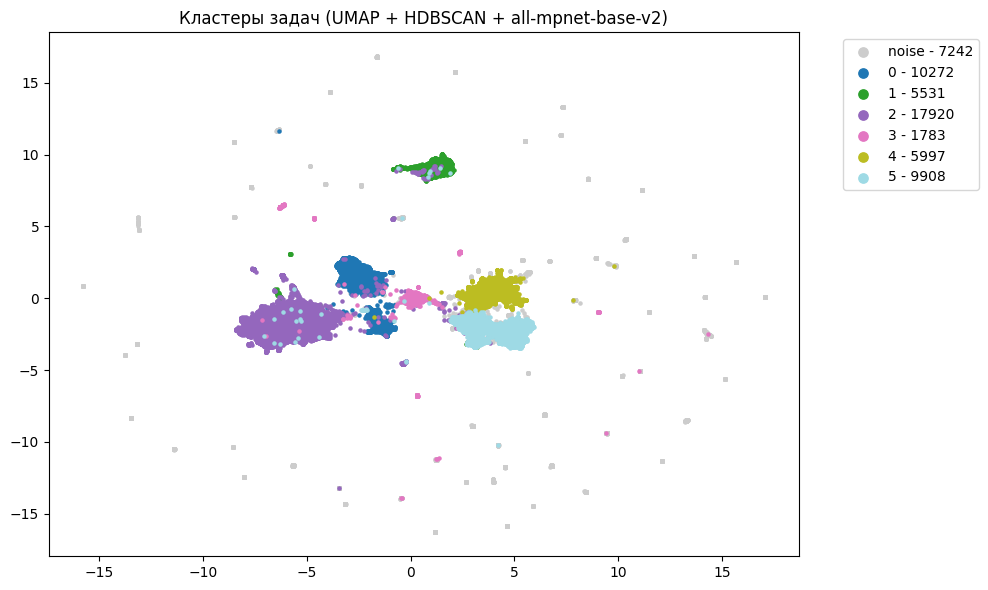

In [149]:
plt.figure(figsize=(10, 6))

for cluster in np.unique(clusters):
    mask = clusters == cluster
    
    plt.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        c=[cluster_colors[cluster]],
        s=5,
        label=cluster_names.get(cluster, f"cluster {cluster}")
    )

plt.title("Кластеры задач (UMAP + HDBSCAN + all-mpnet-base-v2)")
plt.legend(markerscale=3, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

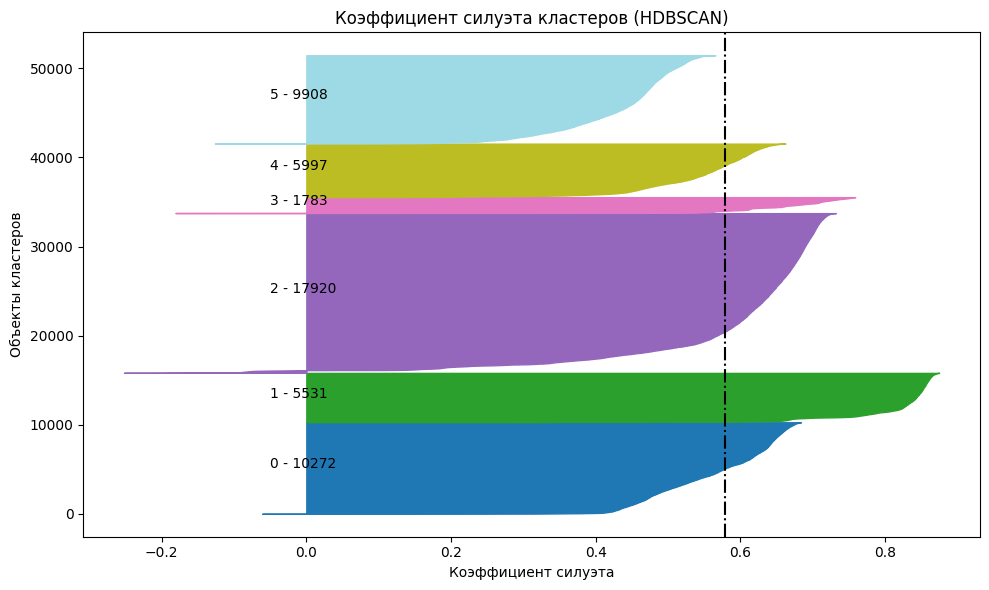

In [135]:
plt.figure(figsize=(10, 6))
y_lower = 10

for cluster in unique_clusters:
    cluster_vals = sample_values[labels == cluster]
    cluster_vals.sort()
    size = len(cluster_vals)
    y_upper = y_lower + size
    
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0,
                      cluster_vals, color=cluster_colors[cluster])

    plt.text(-0.05, (y_lower + y_upper) / 2, cluster_names.get(cluster, str(cluster)))
    y_lower = y_upper + 10

plt.axvline(x=avg_score, linestyle="dashdot", color="black")
plt.title("Коэффициент силуэта кластеров (HDBSCAN)")
plt.xlabel("Коэффициент силуэта")
plt.ylabel("Объекты кластеров")
plt.tight_layout()
plt.show()

In [136]:
avg_score = silhouette_score(X, labels)
print("средний силуэтный коэффициент:", avg_score)

средний силуэтный коэффициент: 0.5784667


In [137]:
noise_ratio = np.mean(clusters==-1)
print("Доля шума:", noise_ratio)

Доля шума: 0.12347194516904506


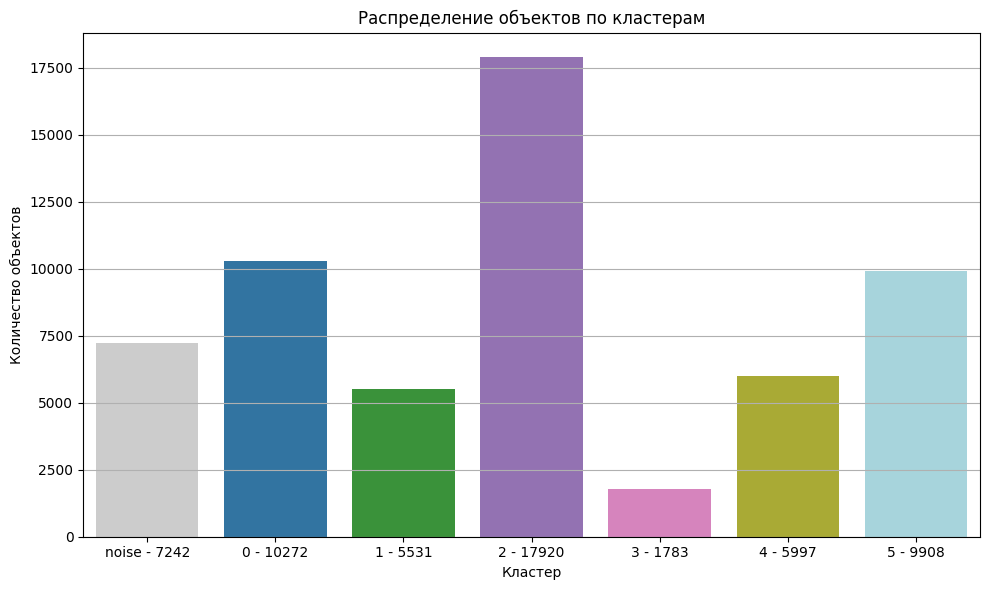

In [151]:
cluster_counts = df["cluster_hdbscan"].value_counts().sort_index()

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=labels,
    y=cluster_counts.values,
    hue=[cluster_names.get(i, f"{i}") for i in cluster_counts.index],   
    palette=[cluster_colors[i] for i in cluster_counts.index],
    legend=False
)

plt.title('Распределение объектов по кластерам')
plt.xlabel('Кластер')
plt.ylabel('Количество объектов')
plt.xticks()
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [152]:
# Примеры задач из кластера

def show_cluster(cluster_id, n=5):
    
    samples = df[df.cluster_hdbscan == cluster_id].sample(n)
    
    for t in samples["task_text"]:
        print(t)
        print("------------------------------------")

In [154]:
show_cluster(4, n=5)

Question: The actress, who played Janet in "Dr. Finlay's Casebook", was nominated for the BAFTA Award for Best Actress in a Supporting Role for a 1976 film that is a retelling of the classic fairy tale Maggie O'Neill.
Options: ['SUPPORTS', 'REFUTES']
------------------------------------
Question: 1: Chinese politician, Chen Xunqiu, was named as chief of this party in 1996. 2: That party and Yangzhong are both cities in China.
Options: ['SUPPORTS', 'REFUTES']
------------------------------------
Question: You're Next movie was filmed after "The Guest" .
Options: ['SUPPORTS', 'REFUTES']
------------------------------------
Question: Greater Swiss Mountain Dog and Harrier are both dog breeds.
Options: ['SUPPORTS', 'REFUTES']
------------------------------------
Question: In between the film based on coach Herman Boone, and My Favorite Martian the film that grossed $36.8 million domestically was My Favorite Martian .
Options: ['SUPPORTS', 'REFUTES']
------------------------------------


In [155]:
show_cluster(5, n=5)

Question: "Falling Away from Me" is a song by American band Korn, was released as the first single from their fourth album "Issues", debuting in an episode of Comedy Central's animated series "South Park", entitled "Korn's Groovy Pirate Ghost Mystery", it was the which number episode of the third season, and the 41st overall?
------------------------------------
Question: The female host of Carousel (comics) creates comic adaptions of literature classics like Waiting for Godot mixed with the MTV's animated series which Daria Morgendorffer is a character becoming ""Waiting for Go". They are presented under the series title "Masterpiece Comics".
Options: ['SUPPORTS', 'REFUTES']
------------------------------------
Question: Who holds England's record for goals in FIFA World Cup finals and presented for BBC Sports Personality of the Year?
------------------------------------
Question: What duet performed Peace on Earth/Little Drummer Boy
------------------------------------
Question: Prou

In [156]:
df.to_csv(
    "/kaggle/working/benchmarks_tasks.csv",
    index=False
)

In [157]:
df.to_json(
    "/kaggle/working/clustering_tasks.jsonl",
    orient="records",
    lines=True
)